<a href="https://colab.research.google.com/github/mewtwox44/ML-SKILL/blob/main/week_8_Skill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving train_titani.csv to train_titani.csv
Dataset loaded successfully!
File: train_titani.csv

========== FIRST 5 ROWS ==========
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   

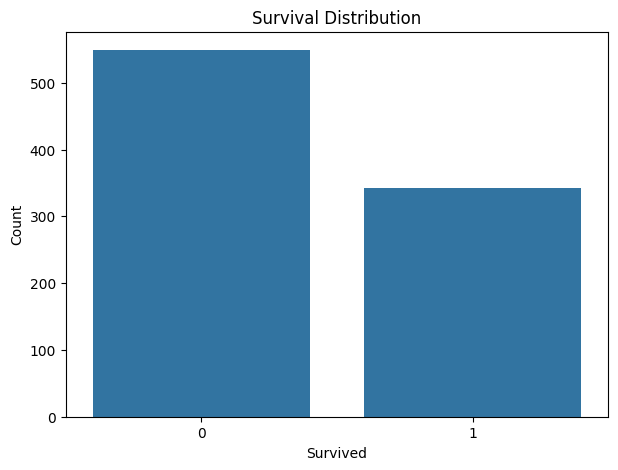

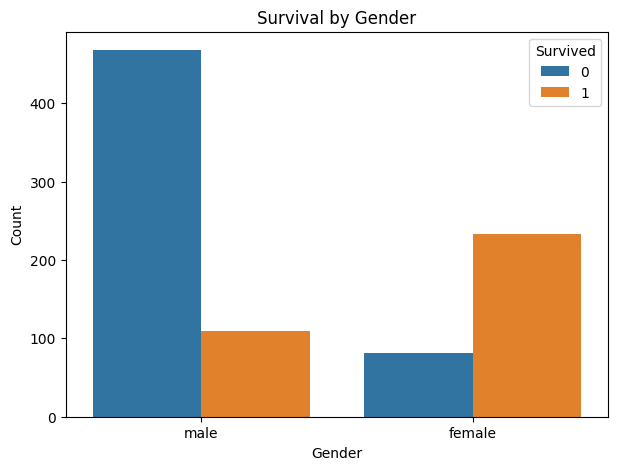

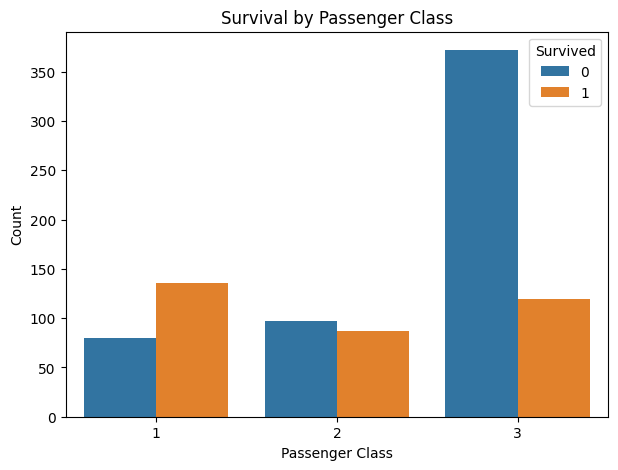


========== FEATURES AFTER ENCODING ==========
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500         1           0           1
1       1  38.0      1      0  71.2833         0           0           0
2       3  26.0      0      0   7.9250         0           0           1
3       1  35.0      1      0  53.1000         0           0           1
4       3  35.0      0      0   8.0500         1           0           1

========== MISSING VALUES AFTER CLEANING ==========
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

========== TRAIN-TEST SPLIT ==========
Training samples: 712
Testing samples : 179

========== GINI DECISION TREE ==========
Accuracy : 0.7654
Precision: 0.7547
Recall   : 0.5797
F1 Score : 0.6557

========== GINI CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0      

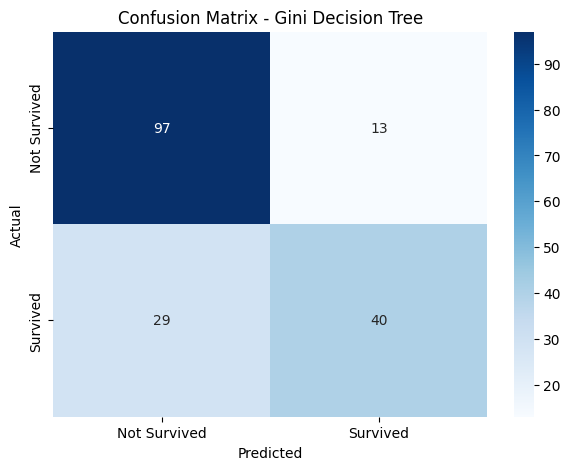

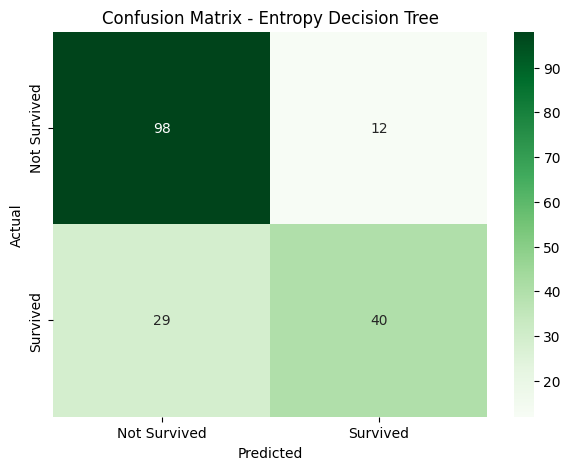

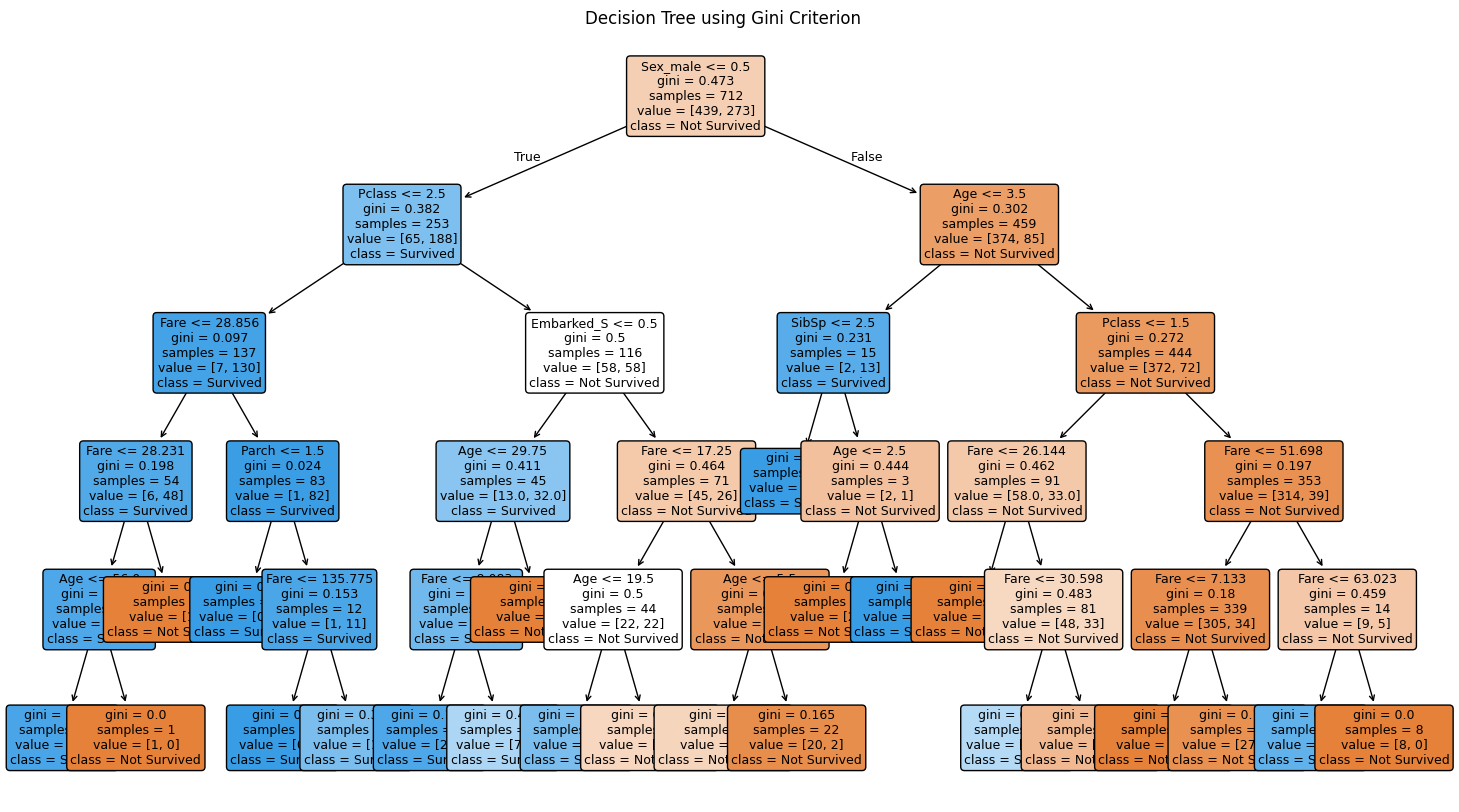


========== FEATURE IMPORTANCE ==========
      Feature  Importance
5    Sex_male    0.530655
0      Pclass    0.180404
1         Age    0.129043
4        Fare    0.113752
7  Embarked_S    0.034252
2       SibSp    0.011150
3       Parch    0.000745
6  Embarked_Q    0.000000


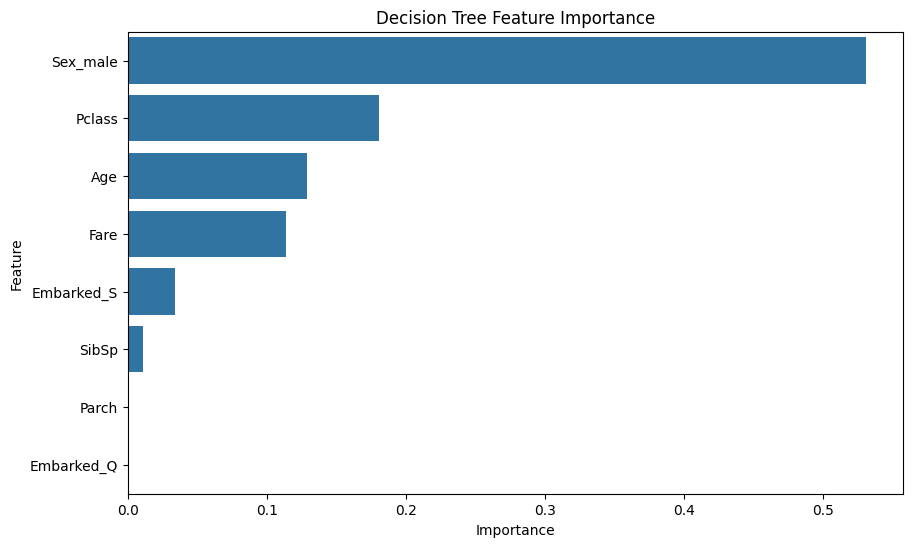


========== ACTUAL VS PREDICTED ==========
    Actual  Gini Prediction  Entropy Prediction
0        0                0                   0
1        0                0                   0
2        1                0                   0
3        0                0                   0
4        1                1                   1
5        1                0                   0
6        1                1                   1
7        0                1                   1
8        0                0                   0
9        0                0                   0
10       0                0                   0
11       0                0                   0
12       1                0                   0
13       0                0                   0
14       0                0                   0
15       0                0                   0
16       0                0                   0
17       0                0                   0
18       0                0                  

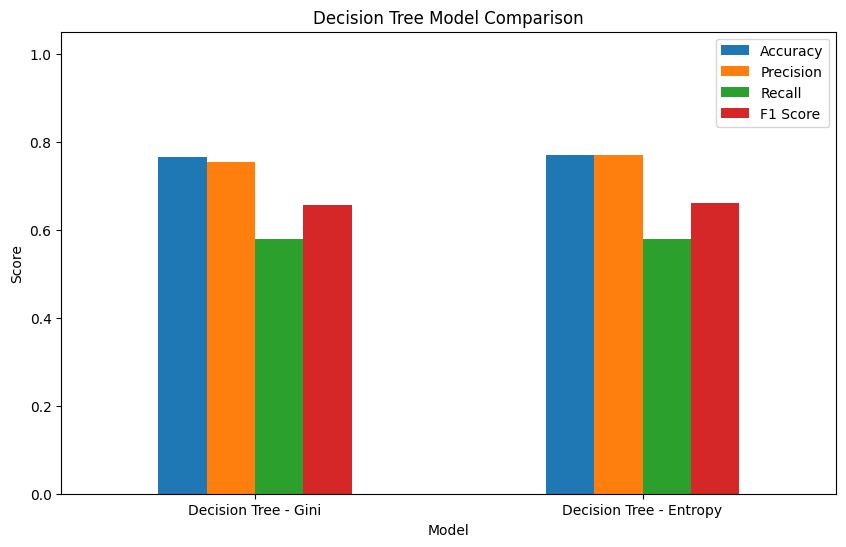


========== TREE DEPTH ANALYSIS ==========
   Depth  Training Accuracy  Testing Accuracy
0      1           0.789326          0.776536
1      2           0.804775          0.759777
2      3           0.832865          0.793296
3      4           0.841292          0.787709
4      5           0.865169          0.765363
5      6           0.884831          0.787709
6      7           0.890449          0.804469
7      8           0.914326          0.804469
8      9           0.929775          0.804469
9     10           0.942416          0.798883


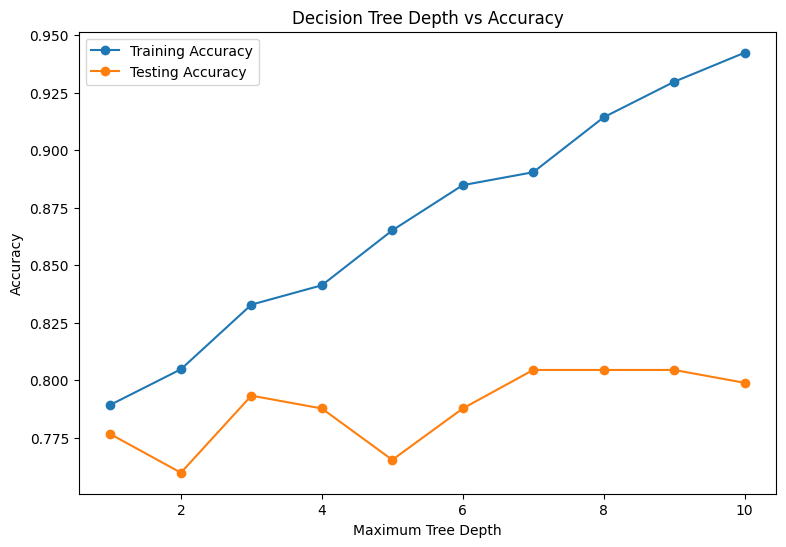


FINAL CONCLUSION
Decision Tree Classification was successfully implemented on the Titanic dataset.
Categorical variables were converted into numerical values using One-Hot Encoding.
Two Decision Tree criteria, Gini and Entropy, were evaluated.
The better performing model in this experiment was the Entropy Decision Tree.
The best accuracy obtained was 0.7709.
The confusion matrix, classification report, feature importance and tree visualization were used to evaluate the model.
Tree depth analysis was also performed to observe the effect of tree complexity on training and testing accuracy.

Project 8 completed successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File:", filename)

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print(df.duplicated().sum())

target = "Survived"

print("\nTarget variable:", target)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=target
)

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features].copy()

y = df[target].copy()

X["Age"] = X["Age"].fillna(
    X["Age"].median()
)

X["Fare"] = X["Fare"].fillna(
    X["Fare"].median()
)

X["Embarked"] = X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

print("\n========== FEATURES AFTER ENCODING ==========")
print(X.head())

print("\n========== MISSING VALUES AFTER CLEANING ==========")
print(X.isnull().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========== TRAIN-TEST SPLIT ==========")
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

gini_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

gini_model.fit(
    X_train,
    y_train
)

gini_pred = gini_model.predict(
    X_test
)

gini_accuracy = accuracy_score(
    y_test,
    gini_pred
)

gini_precision = precision_score(
    y_test,
    gini_pred
)

gini_recall = recall_score(
    y_test,
    gini_pred
)

gini_f1 = f1_score(
    y_test,
    gini_pred
)

print("\n========== GINI DECISION TREE ==========")
print("Accuracy :", round(gini_accuracy, 4))
print("Precision:", round(gini_precision, 4))
print("Recall   :", round(gini_recall, 4))
print("F1 Score :", round(gini_f1, 4))

print("\n========== GINI CLASSIFICATION REPORT ==========")
print(
    classification_report(
        y_test,
        gini_pred
    )
)

entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

entropy_model.fit(
    X_train,
    y_train
)

entropy_pred = entropy_model.predict(
    X_test
)

entropy_accuracy = accuracy_score(
    y_test,
    entropy_pred
)

entropy_precision = precision_score(
    y_test,
    entropy_pred
)

entropy_recall = recall_score(
    y_test,
    entropy_pred
)

entropy_f1 = f1_score(
    y_test,
    entropy_pred
)

print("\n========== ENTROPY DECISION TREE ==========")
print("Accuracy :", round(entropy_accuracy, 4))
print("Precision:", round(entropy_precision, 4))
print("Recall   :", round(entropy_recall, 4))
print("F1 Score :", round(entropy_f1, 4))

print("\n========== ENTROPY CLASSIFICATION REPORT ==========")
print(
    classification_report(
        y_test,
        entropy_pred
    )
)

gini_cm = confusion_matrix(
    y_test,
    gini_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    gini_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Confusion Matrix - Gini Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

entropy_cm = confusion_matrix(
    y_test,
    entropy_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    entropy_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Confusion Matrix - Entropy Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(18, 10))

plot_tree(
    gini_model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree using Gini Criterion")

plt.show()

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gini_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========")
print(feature_importance_df)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Gini Prediction": gini_pred,
    "Entropy Prediction": entropy_pred
})

print("\n========== ACTUAL VS PREDICTED ==========")
print(comparison_df.head(20))

performance_df = pd.DataFrame({
    "Model": [
        "Decision Tree - Gini",
        "Decision Tree - Entropy"
    ],
    "Accuracy": [
        gini_accuracy,
        entropy_accuracy
    ],
    "Precision": [
        gini_precision,
        entropy_precision
    ],
    "Recall": [
        gini_recall,
        entropy_recall
    ],
    "F1 Score": [
        gini_f1,
        entropy_f1
    ]
})

print("\n========== MODEL COMPARISON ==========")
print(performance_df)

performance_plot = performance_df.set_index(
    "Model"
)

performance_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Decision Tree Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.show()

depths = range(1, 11)

depth_results = []

for depth in depths:

    tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    tree.fit(
        X_train,
        y_train
    )

    train_accuracy = tree.score(
        X_train,
        y_train
    )

    test_accuracy = tree.score(
        X_test,
        y_test
    )

    depth_results.append({
        "Depth": depth,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy
    })

depth_df = pd.DataFrame(
    depth_results
)

print("\n========== TREE DEPTH ANALYSIS ==========")
print(depth_df)

plt.figure(figsize=(9, 6))

plt.plot(
    depth_df["Depth"],
    depth_df["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depth_df["Depth"],
    depth_df["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Accuracy")
plt.legend()

plt.show()

best_model = "Gini" if gini_accuracy >= entropy_accuracy else "Entropy"

best_accuracy = max(
    gini_accuracy,
    entropy_accuracy
)

print("\n===================================================")
print("FINAL CONCLUSION")
print("===================================================")

print(
    "Decision Tree Classification was successfully "
    "implemented on the Titanic dataset."
)

print(
    "Categorical variables were converted into numerical "
    "values using One-Hot Encoding."
)

print(
    "Two Decision Tree criteria, Gini and Entropy, "
    "were evaluated."
)

print(
    f"The better performing model in this experiment "
    f"was the {best_model} Decision Tree."
)

print(
    f"The best accuracy obtained was {best_accuracy:.4f}."
)

print(
    "The confusion matrix, classification report, "
    "feature importance and tree visualization were "
    "used to evaluate the model."
)

print(
    "Tree depth analysis was also performed to observe "
    "the effect of tree complexity on training and "
    "testing accuracy."
)

print("\nProject 8 completed successfully!")